# Kunci Jawaban - Linear Regression

- **Dataset:** Airfoil Self-Noise
- **Target:** `scaled-sound-pressure`
- **Jenis masalah:** Regression
- **Model:** Linear Regression

## 1 - Setup

### Install library tambahan

Install `ucimlrepo` terlebih dahulu agar dataset dari UCI Machine Learning Repository bisa diambil langsung di Google Colab.

In [1]:
%pip install -q ucimlrepo

### Import library utama

Import library utama berikut:

- `warnings`: mengatur tampilan warning.
- `numpy`: membantu perhitungan numerik, terutama RMSE.
- `pandas`: membaca, menyimpan, dan mengolah data berbentuk tabel.
- `matplotlib.pyplot`: membuat visualisasi dasar seperti histogram, bar plot, line plot, dan scatter plot.
- `seaborn`: membuat visualisasi statistik seperti histogram dengan KDE, line plot, dan regression plot.

In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Import fungsi dan class tambahan

Import fungsi dan class berikut dari package yang lebih besar:

- `fetch_ucirepo`: mengambil dataset langsung dari UCI Machine Learning Repository.
- `train_test_split`: membagi data menjadi data train dan data test.
- `StandardScaler`: menyamakan skala fitur numerik.
- `LinearRegression`: membuat dan melatih model regresi linear.
- `mean_absolute_error`: menghitung MAE.
- `mean_squared_error`: menghitung MSE dan RMSE.
- `r2_score`: menghitung R2 Score.

In [3]:
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Matikan warning yang tidak diperlukan

Matikan warning agar tampilan notebook lebih bersih.

In [4]:
warnings.filterwarnings("ignore")

### Atur tampilan angka

Atur tampilan angka agar tabel lebih mudah dibaca.

In [5]:
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="whitegrid")

## 2 - Load Dataset

### Ambil dataset dari UCI

Ambil dataset Airfoil Self-Noise menggunakan ID dataset dari UCI.

In [6]:
airfoil = fetch_ucirepo(id=291)

### Ambil fitur dari dataset

Simpan fitur dataset ke variabel `X_raw`.

In [7]:
X_raw = airfoil.data.features.copy()

### Ambil target dari dataset

Simpan target dataset ke variabel `y_raw`.

In [8]:
y_raw = airfoil.data.targets.copy()

### Tentukan kolom target

Tentukan kolom `scaled-sound-pressure` sebagai target prediksi.

In [9]:
TARGET_COL = "scaled-sound-pressure"

### Gabungkan fitur dan target

Gabungkan fitur dan target menjadi satu DataFrame bernama `df`.

In [10]:
df = pd.concat([X_raw, y_raw], axis=1)

### Tampilkan ukuran dataset

Tampilkan jumlah baris dan kolom pada dataset.

In [11]:
df.shape

(1503, 6)

> Berdasarkan output, berapa jumlah baris dan kolom pada dataset?

Jawaban: Dataset memiliki 1503 baris dan 6 kolom.

### Tampilkan lima baris pertama

Tampilkan lima baris pertama untuk melihat contoh isi data.

In [12]:
df.head()

,frequency,attack-angle,chord-length,free-stream-velocity,suction-side-displacement-thickness,scaled-sound-pressure
0,800,0.000,0.305,71.300,0.003,126.201
1,1000,0.000,0.305,71.300,0.003,125.201
2,1250,0.000,0.305,71.300,0.003,125.951
3,1600,0.000,0.305,71.300,0.003,127.591
4,2000,0.000,0.305,71.300,0.003,127.461


> Berdasarkan lima baris pertama, apakah semua kolom berisi angka?

Jawaban: Ya. Semua kolom berisi angka.

> Kolom apa yang menjadi target prediksi?

Jawaban: Kolom target prediksi adalah `scaled-sound-pressure`.

## 3 - Data Understanding

### Tampilkan informasi dataset

Tampilkan informasi struktur dataset menggunakan `info()`.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 6 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   frequency                            1503 non-null   int64  
 1   attack-angle                         1503 non-null   float64
 2   chord-length                         1503 non-null   float64
 3   free-stream-velocity                 1503 non-null   float64
 4   suction-side-displacement-thickness  1503 non-null   float64
 5   scaled-sound-pressure                1503 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 70.6 KB


> Berdasarkan output `info()`, apa tipe data yang muncul pada dataset?

Jawaban: Dataset memiliki tipe data `int64` dan `float64`.

> Apakah jumlah non-null menunjukkan adanya missing value?

Jawaban: Tidak. Semua kolom memiliki 1503 non-null, sama dengan jumlah baris dataset.

### Cek missing value

Hitung jumlah missing value pada setiap kolom.

In [14]:
df.isna().sum()

frequency                              0
attack-angle                           0
chord-length                           0
free-stream-velocity                   0
suction-side-displacement-thickness    0
scaled-sound-pressure                  0
dtype: int64

> Berdasarkan output, kolom mana yang memiliki missing value?

Jawaban: Tidak ada kolom yang memiliki missing value.

### Cek jumlah duplikat

Hitung jumlah baris duplikat penuh pada dataset.

In [15]:
df.duplicated().sum()

np.int64(0)

> Berdasarkan output, berapa jumlah baris duplikat penuh?

Jawaban: Jumlah baris duplikat penuh adalah 0.

### Tampilkan statistik deskriptif

Tampilkan statistik deskriptif untuk seluruh kolom numerik.

In [16]:
df.describe()

,frequency,attack-angle,chord-length,free-stream-velocity,suction-side-displacement-thickness,scaled-sound-pressure
count,1503.000,1503.000,1503.000,1503.000,1503.000,1503.000
mean,2886.381,6.782,0.137,50.861,0.011,124.836
std,3152.573,5.918,0.094,15.573,0.013,6.899
min,200.000,0.000,0.025,31.700,0.000,103.380
25%,800.000,2.000,0.051,39.600,0.003,120.191
50%,1600.000,5.400,0.102,39.600,0.005,125.721
75%,4000.000,9.900,0.229,71.300,0.016,129.995
max,20000.000,22.200,0.305,71.300,0.058,140.987


> Berdasarkan statistik deskriptif, bagaimana perbedaan skala antar fitur?

Jawaban: Skala fitur berbeda jauh. Contohnya, `frequency` mencapai 20000, sedangkan `chord-length` dan `suction-side-displacement-thickness` bernilai kecil.

> Mengapa scaling penting untuk dataset ini?

Jawaban: Scaling penting agar fitur dengan skala besar tidak mendominasi proses pelatihan model.

## 4 - Data Cleaning

### Hapus baris duplikat

Hapus baris duplikat penuh agar data lebih bersih.

In [17]:
df_clean = df.drop_duplicates().copy()

### Reset index dataset

Reset index setelah proses cleaning.

In [18]:
df_clean = df_clean.reset_index(drop=True)

### Cek ukuran data setelah cleaning

Tampilkan ukuran dataset setelah proses cleaning.

In [19]:
df_clean.shape

(1503, 6)

> Berdasarkan output, berapa ukuran dataset setelah duplikat dihapus?

Jawaban: Ukuran dataset tetap 1503 baris dan 6 kolom.

### Cek ulang duplikat

Pastikan tidak ada baris duplikat penuh setelah cleaning.

In [20]:
df_clean.duplicated().sum()

np.int64(0)

> Berdasarkan output, apakah masih ada baris duplikat setelah cleaning?

Jawaban: Tidak ada baris duplikat setelah cleaning.

## 5 - Exploratory Data Analysis

### Tampilkan statistik target

Tampilkan statistik deskriptif khusus untuk target `scaled-sound-pressure`.

In [21]:
df_clean[TARGET_COL].describe()

count   1503.000
mean     124.836
std        6.899
min      103.380
25%      120.191
50%      125.721
75%      129.995
max      140.987
Name: scaled-sound-pressure, dtype: float64

> Berdasarkan output, berapa nilai mean, minimum, dan maksimum target?

Jawaban: Mean target sekitar 124.836, minimum 103.380, dan maksimum 140.987.

### Buat histogram target

Gunakan histogram dengan KDE untuk melihat distribusi target `scaled-sound-pressure`.

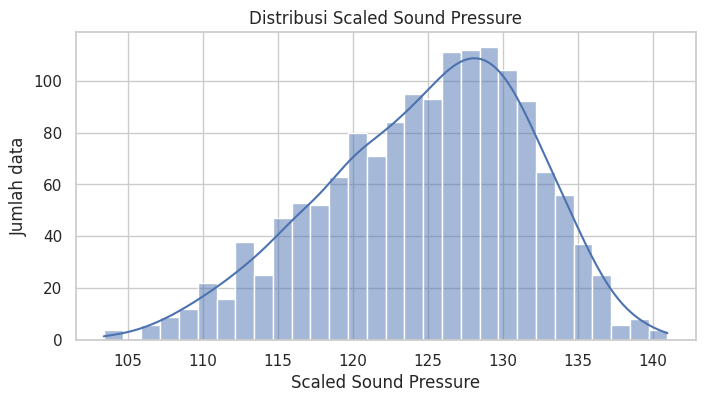

In [22]:
plt.figure(figsize=(8, 4))
sns.histplot(df_clean[TARGET_COL], bins=30, kde=True)
plt.title("Distribusi Scaled Sound Pressure")
plt.xlabel("Scaled Sound Pressure")
plt.ylabel("Jumlah data")
plt.show()

> Berdasarkan histogram, di rentang mana nilai target paling banyak muncul?

Jawaban: Nilai target paling banyak muncul pada rentang sekitar 128.451 sampai 129.705.

> Apakah distribusi target terlihat sangat miring atau relatif menyebar di sekitar tengah?

Jawaban: Distribusi target relatif menyebar di sekitar nilai tengah dan tidak semiring beberapa dataset harga atau jumlah.

### Hitung korelasi fitur numerik dengan target

Hitung korelasi fitur numerik terhadap target `scaled-sound-pressure`.

In [23]:
numeric_corr = df_clean.corr()[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)
numeric_corr

free-stream-velocity                   0.125
attack-angle                          -0.156
chord-length                          -0.236
suction-side-displacement-thickness   -0.313
frequency                             -0.391
Name: scaled-sound-pressure, dtype: float64

> Berdasarkan output korelasi, fitur apa yang memiliki korelasi positif terhadap target?

Jawaban: `free-stream-velocity` memiliki korelasi positif terhadap target.

> Fitur apa yang memiliki korelasi negatif paling kuat terhadap target?

Jawaban: `frequency` memiliki korelasi negatif paling kuat terhadap target.

### Buat bar plot korelasi numerik

Gunakan bar plot untuk melihat kekuatan korelasi fitur numerik dengan target.

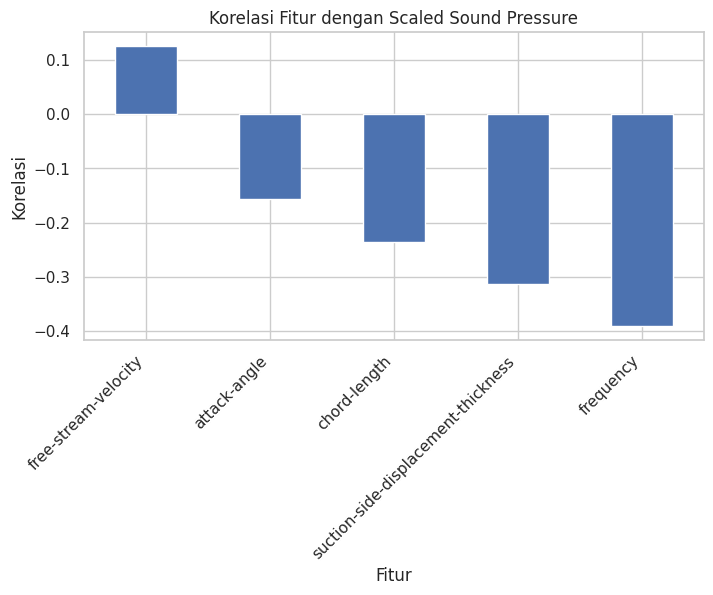

In [24]:
plt.figure(figsize=(8, 4))
numeric_corr.plot(kind="bar")
plt.title("Korelasi Fitur dengan Scaled Sound Pressure")
plt.xlabel("Fitur")
plt.ylabel("Korelasi")
plt.xticks(rotation=45, ha="right")
plt.show()

> Berdasarkan bar plot, fitur mana yang berada pada sisi korelasi positif?

Jawaban: `free-stream-velocity` berada pada sisi korelasi positif.

> Fitur mana yang berada pada sisi korelasi negatif?

Jawaban: `attack-angle`, `chord-length`, `suction-side-displacement-thickness`, dan `frequency` berada pada sisi korelasi negatif.

### Buat line plot rata-rata target berdasarkan frequency

Gunakan line plot untuk melihat rata-rata target pada setiap nilai `frequency`.

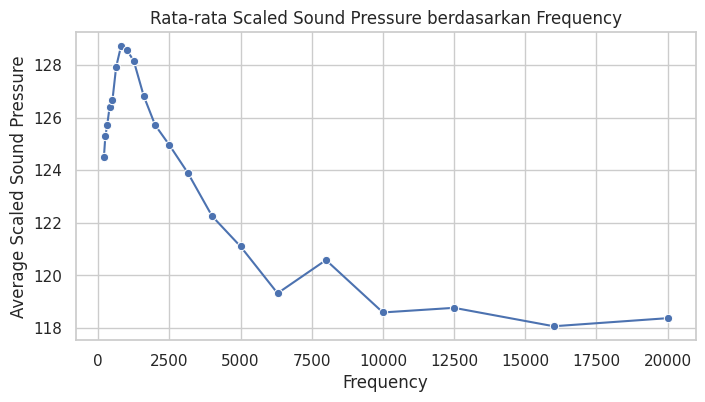

In [25]:
frequency_mean = df_clean.groupby("frequency")[TARGET_COL].mean().reset_index()

plt.figure(figsize=(8, 4))
sns.lineplot(data=frequency_mean, x="frequency", y=TARGET_COL, marker="o")
plt.title("Rata-rata Scaled Sound Pressure berdasarkan Frequency")
plt.xlabel("Frequency")
plt.ylabel("Average Scaled Sound Pressure")
plt.show()

> Berdasarkan line plot, bagaimana perubahan rata-rata target saat frequency semakin tinggi?

Jawaban: Rata-rata target cenderung menurun pada frequency yang lebih tinggi.

> Mengapa line plot lebih tepat daripada scatter plot untuk `frequency` pada bagian ini?

Jawaban: Line plot lebih tepat karena `frequency` memiliki nilai level berurutan, sehingga rata-rata per level lebih mudah dibaca sebagai pola.

### Buat scatter plot suction-side-displacement-thickness dan target

Gunakan scatter plot dengan garis regresi untuk melihat hubungan fitur kontinu dengan target.

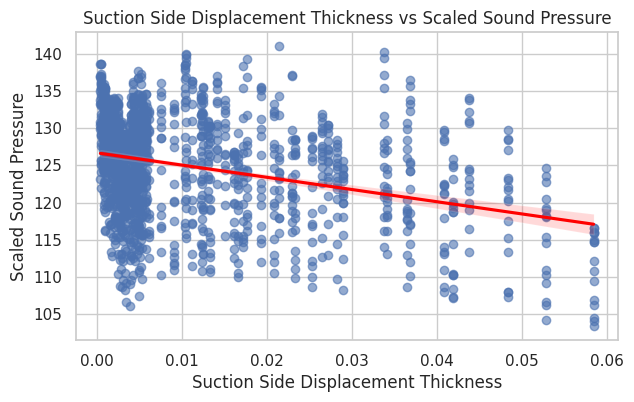

In [26]:
plt.figure(figsize=(7, 4))
sns.regplot(
    data=df_clean,
    x="suction-side-displacement-thickness",
    y=TARGET_COL,
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)
plt.title("Suction Side Displacement Thickness vs Scaled Sound Pressure")
plt.xlabel("Suction Side Displacement Thickness")
plt.ylabel("Scaled Sound Pressure")
plt.show()

> Berdasarkan scatter plot, bagaimana pola hubungan fitur ini dengan target?

Jawaban: Hubungannya cenderung negatif; nilai thickness yang lebih besar cenderung berkaitan dengan scaled sound pressure yang lebih rendah.

> Apakah garis regresi menunjukkan arah hubungan positif atau negatif?

Jawaban: Garis regresi menunjukkan arah hubungan negatif.

## 6 - Feature dan Target

### Pisahkan fitur awal

Pisahkan semua kolom selain target sebagai fitur awal.

In [27]:
X_raw_model = df_clean.drop(columns=[TARGET_COL])

### Pisahkan target

Simpan kolom target ke dalam variabel `y`.

In [28]:
y = df_clean[TARGET_COL]

### Gunakan fitur numerik

Gunakan fitur numerik yang sudah tersedia karena dataset ini tidak memiliki kolom kategori.

In [29]:
X = X_raw_model.copy()

### Tampilkan ukuran fitur

Tampilkan ukuran `X` yang akan digunakan untuk modeling.

In [30]:
X.shape

(1503, 5)

> Berdasarkan output, berapa jumlah baris dan fitur pada `X`?

Jawaban: `X` memiliki 1503 baris dan 5 fitur.

### Tampilkan ukuran target

Tampilkan ukuran `y` sebagai target model.

In [31]:
y.shape

(1503,)

> Berdasarkan output, berapa jumlah nilai target pada `y`?

Jawaban: `y` memiliki 1503 nilai target.

## 7 - Train-Test Split

### Tentukan parameter split

Tentukan `test_size` dan `random_state` yang akan digunakan.

In [32]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

> Berdasarkan nilai `test_size`, berapa persen data uji dan berapa persen data latih yang digunakan?

Jawaban: Data uji sebanyak 20% dan data latih sebanyak 80%.

### Bagi data train dan test

Bagi fitur dan target menjadi data train dan data test.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

### Tampilkan ukuran X_train

Tampilkan ukuran fitur pada data train.

In [34]:
X_train.shape

(1202, 5)

### Tampilkan ukuran X_test

Tampilkan ukuran fitur pada data test.

In [35]:
X_test.shape

(301, 5)

> Berdasarkan output, berapa jumlah baris pada data train dan data test?

Jawaban: Data train memiliki 1202 baris dan data test memiliki 301 baris.

## 8 - Feature Scaling

### Buat object scaler

Buat object `StandardScaler` untuk menyamakan skala fitur.

In [36]:
scaler = StandardScaler()

### Fit dan transform data train

Fit scaler pada data train, lalu ubah data train ke skala standar.

In [37]:
X_train_scaled = scaler.fit_transform(X_train)

### Transform data test

Ubah data test menggunakan scaler yang sudah di-fit pada data train.

In [38]:
X_test_scaled = scaler.transform(X_test)

## 9 - Linear Regression Model

### Buat model Linear Regression

Buat object model Linear Regression.

In [39]:
model = LinearRegression()

### Latih model

Latih model menggunakan data train yang sudah di-scale.

In [40]:
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


> Berdasarkan output, apa tanda bahwa model Linear Regression sudah berhasil dilatih dan siap digunakan?

Jawaban: Output menampilkan object `LinearRegression()`, yang berarti model berhasil dibuat dan dilatih.

### Tampilkan intercept model

Tampilkan nilai intercept dari model Linear Regression.

In [41]:
model.intercept_

np.float64(124.87696006655574)

> Berdasarkan output, berapa nilai intercept model?

Jawaban: Nilai intercept model sekitar 124.877.

### Tampilkan koefisien model

Tampilkan koefisien setiap fitur dalam bentuk tabel.

In [42]:
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

coef_table

,Feature,Coefficient
3,free-stream-velocity,1.527
4,suction-side-displacement-thickness,-1.816
1,attack-angle,-2.367
2,chord-length,-3.220
0,frequency,-4.059


> Berdasarkan tabel koefisien, fitur mana yang memiliki koefisien positif terbesar?

Jawaban: Fitur `free-stream-velocity` memiliki koefisien positif terbesar.

> Fitur mana yang memiliki koefisien negatif terbesar arahnya?

Jawaban: Fitur `frequency` memiliki koefisien negatif terbesar arahnya.

## 10 - Prediksi dan Evaluasi

### Buat prediksi data train

Gunakan model untuk membuat prediksi pada data train.

In [43]:
y_train_pred = model.predict(X_train_scaled)

### Buat prediksi data test

Gunakan model untuk membuat prediksi pada data test.

In [44]:
y_test_pred = model.predict(X_test_scaled)

### Tampilkan lima prediksi pertama

Bandingkan lima nilai aktual dan prediksi pertama pada data test.

In [45]:
prediction_preview = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
}).head()

prediction_preview

,Actual,Predicted
0,125.045,124.162
1,118.767,119.718
2,120.233,120.297
3,137.047,129.615
4,134.556,129.756


> Berdasarkan lima prediksi pertama, prediksi mana yang terlihat paling dekat dengan nilai aktual?

Jawaban: Baris ketiga terlihat paling dekat karena actual 120.233 dan predicted sekitar 120.297.

> Prediksi mana yang terlihat paling jauh dari nilai aktual?

Jawaban: Baris keempat terlihat paling jauh karena actual 137.047 dan predicted sekitar 129.615.

### Hitung MAE train

Hitung MAE pada data train.

In [46]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_train

3.753726502765334

### Hitung MAE test

Hitung MAE pada data test.

In [47]:
mae_test = mean_absolute_error(y_test, y_test_pred)
mae_test

3.6724145641788004

> Berdasarkan output, berapa nilai MAE test?

Jawaban: Nilai MAE test sekitar 3.672.

### Hitung RMSE train

Hitung RMSE pada data train.

In [48]:
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_train

np.float64(4.826601301553781)

### Hitung RMSE test

Hitung RMSE pada data test.

In [49]:
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
rmse_test

np.float64(4.704109194974887)

> Berdasarkan output, berapa nilai RMSE test?

Jawaban: Nilai RMSE test sekitar 4.704.

### Hitung R2 train

Hitung R2 Score pada data train.

In [50]:
r2_train = r2_score(y_train, y_train_pred)
r2_train

0.5034475371198581

### Hitung R2 test

Hitung R2 Score pada data test.

In [51]:
r2_test = r2_score(y_test, y_test_pred)
r2_test

0.5582979754897286

> Berdasarkan output, berapa nilai R2 test?

Jawaban: Nilai R2 test sekitar 0.558.

### Buat tabel evaluasi akhir

Gabungkan MAE, RMSE, dan R2 Score untuk data train dan data test.

In [52]:
evaluation_table = pd.DataFrame({
    "Data": ["Train", "Test"],
    "MAE": [mae_train, mae_test],
    "RMSE": [rmse_train, rmse_test],
    "R2 Score": [r2_train, r2_test]
})

evaluation_table

,Data,MAE,RMSE,R2 Score
0,Train,3.754,4.827,0.503
1,Test,3.672,4.704,0.558


> Berdasarkan tabel evaluasi, bagaimana perbandingan MAE train dan MAE test?

Jawaban: MAE test sekitar 2.17% lebih rendah daripada MAE train.

> Berdasarkan tabel evaluasi, bagaimana perbandingan RMSE train dan RMSE test?

Jawaban: RMSE test sekitar 2.54% lebih rendah daripada RMSE train.

> Berdasarkan tabel evaluasi, bagaimana perbandingan R2 train dan R2 test?

Jawaban: R2 test sekitar 10.89% lebih tinggi daripada R2 train.

### Visualisasikan aktual vs prediksi

Gunakan scatter plot untuk membandingkan nilai aktual dan prediksi pada data test.

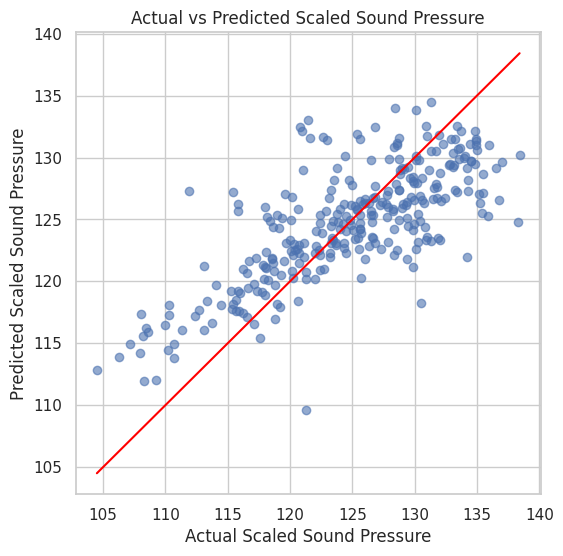

In [53]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.title("Actual vs Predicted Scaled Sound Pressure")
plt.xlabel("Actual Scaled Sound Pressure")
plt.ylabel("Predicted Scaled Sound Pressure")
plt.show()

## 11 - Kesimpulan

Dataset Airfoil Self-Noise digunakan untuk memprediksi `scaled-sound-pressure` berdasarkan fitur eksperimen airfoil. Dataset memiliki 1503 baris dan 6 kolom. Data tidak memiliki missing value dan memiliki 0 baris duplikat penuh.

EDA menunjukkan bahwa target `scaled-sound-pressure` relatif menyebar di sekitar tengah. Fitur yang memiliki korelasi positif terhadap target adalah `free-stream-velocity`, sedangkan fitur dengan korelasi negatif paling kuat adalah `frequency`. Semua fitur sudah numerik, sehingga encoding kategori tidak diperlukan.

Data dibagi menjadi 80% data train dan 20% data test. Berdasarkan evaluasi, MAE test bernilai sekitar 3.672, RMSE test sekitar 4.704, dan R2 test sekitar 0.558.